# SILVA Generative Equilibrium Transformer

This lab separates one-time source encoding from the weight-tied transformer
equilibrium, derives QKV injection, trains a tiny teacher-matching task, and
checks optional class conditioning. The architecture mechanism follows the
Generative Equilibrium Transformer [48]; SILVA supplies the general source,
state, solver, and diagnostic contract.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [4](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [48](https://jseluis.github.io/silva-networks/paper/references/#ref-48). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVAGenerativeEquilibriumTransformer,
    SolverConfig,
    make_teacher_image_pairs,
    silva_distillation_loss,
)

torch.manual_seed(220)

## 1. Patches Become Source Tokens

For patch size $p$, an image $x\in\mathbb R^{B\times C\times H\times W}$
becomes

$$
X_p\in\mathbb R^{B\times N\times d},
\qquad N=\frac Hp\frac Wp.
$$

A patch convolution performs extraction and projection together. Fixed 2D
sine/cosine positions are added before the injection transformer.

In [3]:
data = make_teacher_image_pairs(samples=4, channels=1, height=6, width=6, seed=22)
assert data.equation_residual().abs().max() == 0
print("noise/target:", tuple(data.noise.shape), tuple(data.target.shape))

noise/target: (4, 1, 6, 6) (4, 1, 6, 6)


## 2. Injection Is Computed Once

Let $I_\phi$ be a finite injection transformer. It computes

$$
U=I_\phi(X_p),
\qquad
(U_1,\ldots,U_L)=W_UU,
$$

where every $U_\ell\in\mathbb R^{B\times N\times3d}$ supplies query, key,
and value offsets for one internal equilibrium block. $I_\phi$ is outside the
root solve and is therefore evaluated once per model call.

## 3. QKV-Injected Equilibrium Block

At internal block $\ell$,

$$
(Q,K,V)=Z W_{qkv}^{(\ell)}+U_\ell+C_y,
$$

$$
A_\ell=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_h}}\right)V,
$$

$$
\widetilde Z=Z+A_\ell,
\qquad
Z^+=\tanh\left(s[\widetilde Z+operatorname{FFN}(\widetilde Z)]\right).
$$

$C_y$ is optional class injection. The final bounded map is SILVA's compact
stability envelope; the one-time QKV-injection mechanism is unchanged.

In [4]:
config = SolverConfig(
    solver="picard",
    max_iter=12,
    tol=1e-5,
    anderson_batch_dims=1,
)
model = SILVAGenerativeEquilibriumTransformer(
    in_channels=1,
    patch_size=2,
    hidden_dim=8,
    heads=2,
    injection_depth=1,
    equilibrium_depth=2,
    state_scale=0.15,
    config=config,
)
result = model(data.noise, return_result=True)
assert result.output.shape == data.target.shape
assert result.state.shape == (4, 9, 8)
assert result.injection.shape == (4, 9, 48)
print("solver residual:", result.solver_result.residual)

solver residual: 0.5481676459312439


## 4. One-Step Teacher Matching

The architectural fixed point and the distillation objective answer different
questions. The equilibrium determines the hidden representation. The teaching
loss matches a supplied target:

$$
\mathcal L_{\mathrm{distill}}
=\frac1{BCHW}\|Q(Z^\star)-x_{\mathrm{teacher}}\|_2^2.
$$

The generated smoothing pairs make this pipeline executable without claiming a
diffusion benchmark or a pretrained teacher.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for _ in range(8):
    optimizer.zero_grad()
    prediction = model(data.noise)
    loss = silva_distillation_loss(prediction, data.target)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

trained = model(data.noise, return_result=True)
print("initial/final distillation loss:", losses[0], losses[-1])

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


initial/final distillation loss: 0.22758668661117554 0.17329496145248413


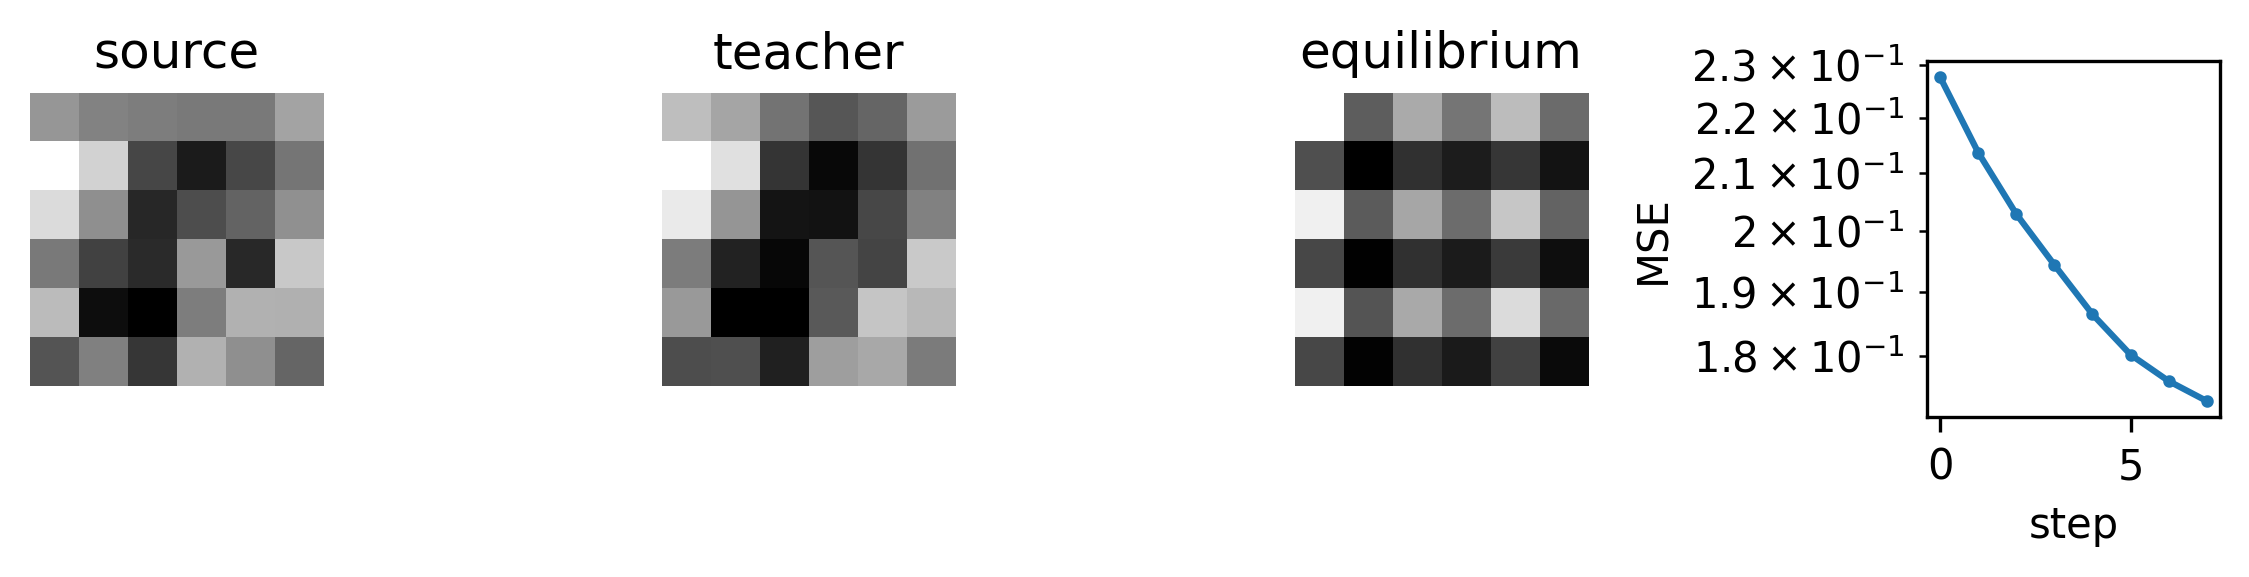

In [6]:
figure, axes = plt.subplots(1, 4, figsize=(7.6, 2.0))
axes[0].imshow(data.noise[0, 0], cmap="gray")
axes[0].set_title("source")
axes[1].imshow(data.target[0, 0], cmap="gray")
axes[1].set_title("teacher")
axes[2].imshow(trained.output.detach()[0, 0], cmap="gray")
axes[2].set_title("equilibrium")
axes[3].plot(losses, marker="o", markersize=2)
axes[3].set(xlabel="step", ylabel="MSE", yscale="log")
for axis in axes[:3]:
    axis.axis("off")
figure.tight_layout()
plt.show()

## 5. Class Conditioning

When `classes` is configured, the class embedding produces another
$3dL$-dimensional source that is split across equilibrium blocks. It shifts
Q, K, and V without changing the token shape or adding class tokens.

In [7]:
conditioned = SILVAGenerativeEquilibriumTransformer(
    in_channels=1,
    patch_size=2,
    hidden_dim=8,
    heads=2,
    equilibrium_depth=1,
    classes=3,
    config=SolverConfig(max_iter=3, anderson_batch_dims=1),
)
conditioned_output = conditioned(data.noise[:2], labels=torch.tensor([0, 2]))
assert conditioned_output.shape == data.target[:2].shape
print("conditioned output:", tuple(conditioned_output.shape))

conditioned output: (2, 1, 6, 6)


## 6. Scaling the Experiment

For a full distillation study, replace the generated pairs with the exact
teacher checkpoint, sampling schedule, image preprocessing, class protocol,
and evaluation metrics from the target experiment. Report both image quality
and equilibrium convergence; parameter count alone does not establish a
distillation result.

## Where to Go Next

| Question | Page |
| --- | --- |
| How is one-time QKV injection derived? | [Advanced Equilibrium Families](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-families/#generative-equilibrium-transformer) |
| What does the generated teacher target satisfy? | [Advanced Equilibrium Datasets](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-datasets/#teacher-image-pairs) |
| Which transformer classes are public? | [Advanced Equilibria API](https://jseluis.github.io/silva-networks/api/advanced_equilibria/) |
